In [1]:
from lattice import Lattice
import pyrochlore
import visual
from pyro_ham_construct import construct_hamiltonian_spec
import numpy as np
import scipy.sparse as sp
import scipy.linalg as sLA
from tqdm import tqdm




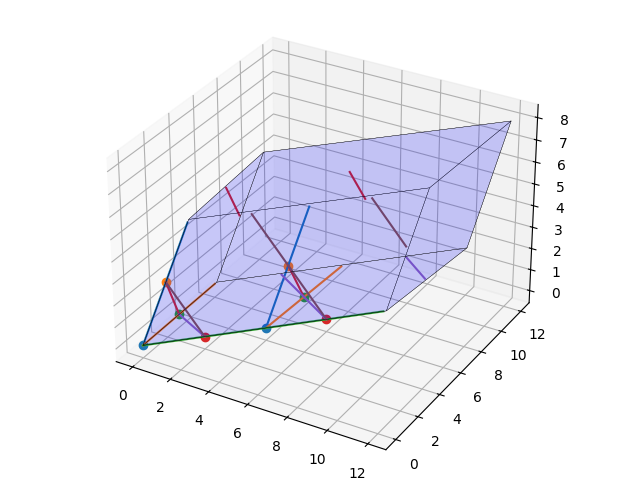

In [6]:
%matplotlib widget
visual.plt.close('all')
l = Lattice(pyrochlore.primitive, [[1,0,0],[0,1,0],[0,0,2]])
fig = visual.plt.figure()
ax = fig.add_axes([0,0,1,1],projection='3d')
visual.plot_unitcell(ax, l)
visual.plot_atoms(ax, l)
visual.plot_bonds(ax, l)

name = "pyro_%d_%d_%d.json" % tuple(l.periodicity)

pyrochlore.export_json(l, "lattice_files/"+name)

In [3]:
l.bonds[0].from_idx, l.bonds[0].to_idx

(0, 8)

In [4]:
def calc_ham_action(Ham, state, hamspec):
    # returns a list of the form [weight, final_state]
    diag_weight = 0.

    for op_kind, op_list in hamspec['static']:
        for bond in op_list:
            coupling_str = bond[0]
            mask_I = (1 << bond[1])
            mask_J = (1 << bond[2])
            
            z_I = state&mask_I
            z_J = state&mask_J
            
            if op_kind == 'zz':
                z1z2 = ( z_I != 0) ^ ( z_J != 0)
                # z1z2 = 0 => spins aligned => should be +1
                diag_weight += coupling_str * (1 - 2*z1z2)
            elif (op_kind == '+-' and z_I == 0 and z_J == mask_J) or (op_kind == '-+' and z_J == 0 and z_I == mask_I):
                Ham[state ^ (mask_I | mask_J), state] = coupling_str

    Ham[state, state] += diag_weight


def calc_ham(hamspec, lat):
    N = lat.num_atoms
    Ham = sp.lil_array((1<<N, 1<<N),dtype=np.complex128)
    for state in range(1<<N):
        calc_ham_action(Ham, state, hamspec)
    return sp.csr_array(Ham)
    

In [5]:
'''
Spits out a sparse matrix corresponding to a particular ring-flip, located on the specified six sites
'''
def calc_rf_operator(rf, N):
    O = sp.lil_array((1<<N, 1<<N))
    
    mask = np.uint64(0)
    target_value = np.uint64(0)
    for i in range(6):
        mask |= (1 << rf[i])
        if i%2 == 0:
            target_value |= (1 << rf[i])

    for state in range(1<<N):
        if state& mask != target_value:
            continue
        
        # flip all six sigma-Z
        new_state = state ^ mask
        O[new_state, state] = 1

    return sp.csr_array(O)